In [1]:
import dnnlib.nlb_util_v2 as nlb_util
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
out_dir = "data"

# mc_maze_with_behavior

In [3]:
train_loader,val_loader,train_data,val_data,metadata = nlb_util.loader_mc_maze_with_behavior()

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/dnnlib/nlb_util_v2.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smoothed_spikes['time_stamp'] = smoothed_spikes.index.total_seconds()


In [4]:
len(train_data)

1721

In [5]:
train_data[0].shape

(3017, 137)

In [6]:
## there are so many trials, let's just focus on specific maze
## trial_type = 1 and trial_version = 0 (1-target no-barrier)
## to include all trials, guess we need to condition on these labels (is cursor position needed?)


# uniques_trType, counts_trType =np.unique(metadata['train']['trial_info']['trial_type'], return_counts=True)
# pd.DataFrame((uniques_trType, counts_trType)).T

# trial_idx_use = np.array(metadata['train']['trial_info']['trial_type']) == 1
# np.array(metadata['train']['trial_info']['maze_id'])[trial_idx_use]
# np.unique(np.array(metadata['train']['trial_info']['trial_version'])[trial_idx_use], return_counts=True)

# cond1 = np.array(metadata['train']['trial_info']['trial_type']) == 1
cond2 = np.array(metadata['train']['trial_info']['trial_version']) == 0
# trial_idx_use = cond1 & cond2
trial_idx_use = cond2
np.sum(trial_idx_use)

592

In [7]:
train_data_new = [item for item, mask in zip(train_data, trial_idx_use) if mask]

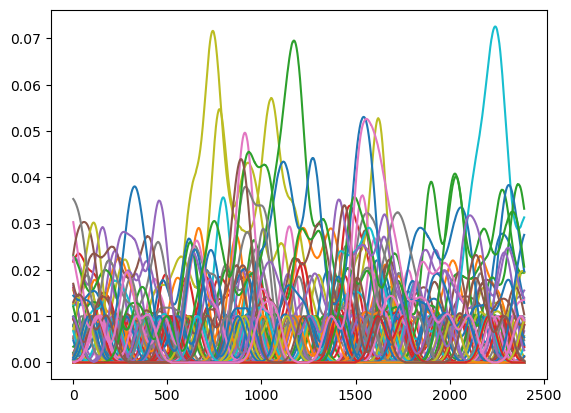

In [8]:
trial_id = 16
plt.plot(train_data_new[trial_id]);

In [9]:
train_all = np.concatenate(train_data_new, axis=0)
means = np.mean(train_all, axis=0)  # Per dimension
stds = np.std(train_all, axis=0)
stds = np.maximum(stds, 1e-8)

In [10]:
for i in range(len(train_data_new)): train_data_new[i] = (train_data_new[i] - means) / stds

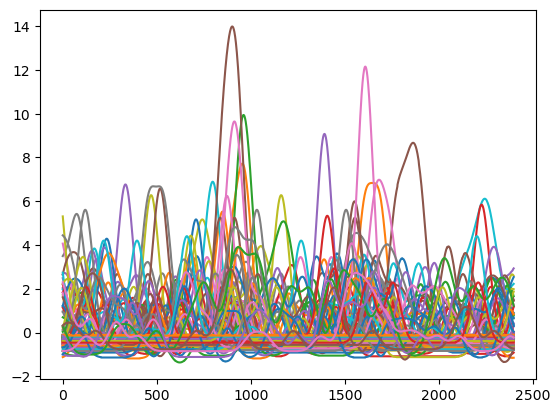

In [11]:
plt.plot(train_data_new[trial_id]);

In [12]:
sub_dir = os.path.join(out_dir, "mc_maze")
os.makedirs(sub_dir, exist_ok=True)
save_path = os.path.join(sub_dir, "dataset_samples.npz")
np.savez(save_path, samples=np.array(train_data_new, dtype=object))

In [13]:
np.save(os.path.join(sub_dir, "mean_std.npy"), [means, stds])

In [14]:
dt = 0.001
cov_dynamic_samples = []
for ii in range(len(train_data_new)):
    cov_dynamic_samples.append(np.arange(train_data_new[ii].shape[0])[:,None]*dt)

In [15]:
np.save(os.path.join(sub_dir, "cov_dynamic_samples.npy"), np.array(cov_dynamic_samples, dtype=object))

In [16]:
len(train_data_new)

592

In [17]:
len(cov_dynamic_samples)

592

Still need to save metadata

In [18]:
np.save(os.path.join(sub_dir, "meta_train.npy"), metadata['train'])

In [19]:
# train_meta = np.load(os.path.join(sub_dir, "meta_train.npy"), allow_pickle=True).tolist()
# train_meta['trial_info'].keys()